#### Basemaps in GIS

The internet says:  A foundational layer on a map that is the basis of GIS visual and geographic context. A basemap may include background reference information such as landforms, roads, landmarks, and administrative boundaries.

One way to do this is to use `contextily`.

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import os

The database we're using is `https://www2.census.gov/geo/tiger/GENZ2019/shp/cb_2019_06_place_500k.zip`.  

Grab the file manually in the browser.

In [17]:
dbpath = os.path.expanduser('~')+'/data/'
fn = 'cb_2019_06_place_500k.zip'
places = gpd.read_file(dbpath + fn)
berkeley = places[places['NAME']=='Berkeley']

The docs say "Bounding boxes can be passed in both WGS84 (EPSG:4326) and Spheric Mercator (EPSG:3857)."

In [18]:
berkeley = berkeley.to_crs('EPSG:3857')

The docs for `contextily.add_basemap`:  it has one required parameter, an `matplotlib.axes`.  Optional:`zoom, source, crs, zoom_adjust` and more.  The zoom level requested is automatically inferred from the bounds of the axes.

1

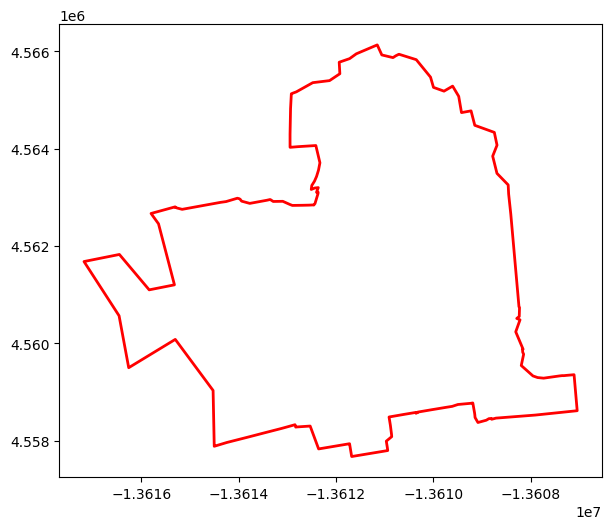

In [19]:
#ax.bbox.bounds
ax = berkeley.plot(ec='r',fc='none',figsize=(7, 7),lw=2)
w,s,e,n = ax.bbox.bounds
cx.tile._calculate_zoom(w,s,e,n)

This is certainly not correct.

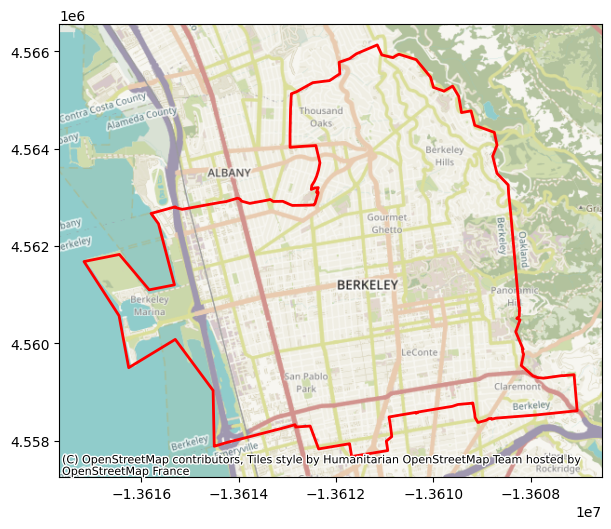

In [20]:
ax = berkeley.plot(ec='r',fc='none',figsize=(7, 7),lw=2)
cx.add_basemap(ax)
plt.show()

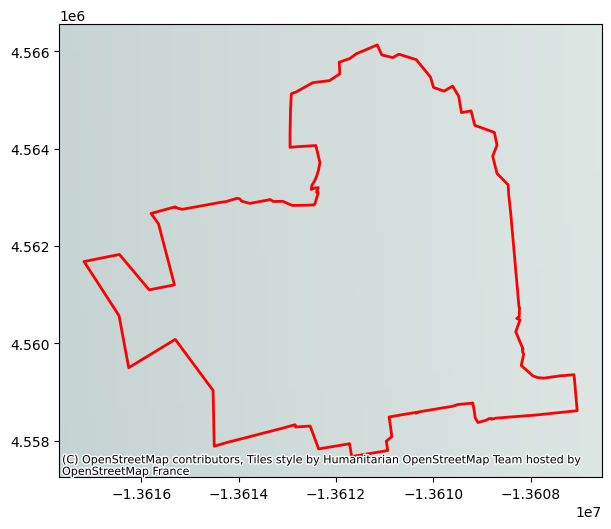

In [21]:
ax = berkeley.plot(ec='r',fc='none',figsize=(7, 7),lw=2)
cx.add_basemap(ax,zoom=2)
plt.show()

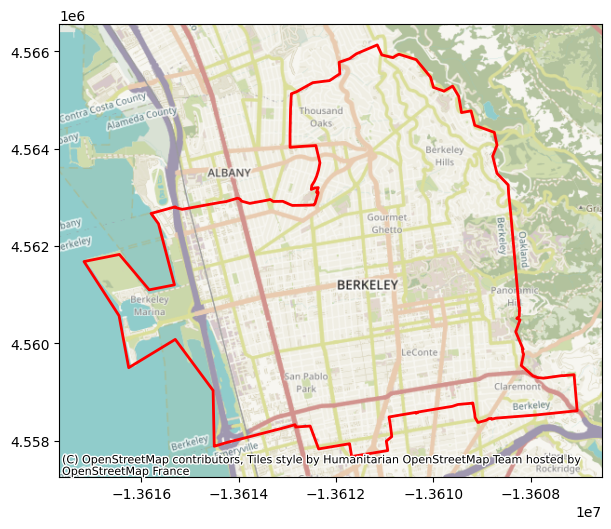

In [22]:
ax = berkeley.plot(ec='r',fc='none',figsize=(7, 7),lw=2)
cx.add_basemap(ax,zoom=13)
plt.show()

In [ ]:
# increase the zoom
ax = berkeley.plot(ec='r',fc='none',figsize=(7, 7),lw=2)
cx.add_basemap(ax,zoom=14)
plt.show()

The default source is OpenStreetMap Humanitarian web tiles.

In [23]:
cx.providers.keys()

dict_keys(['OpenStreetMap', 'MapTilesAPI', 'OpenSeaMap', 'OPNVKarte', 'OpenTopoMap', 'OpenRailwayMap', 'OpenFireMap', 'SafeCast', 'Stadia', 'Thunderforest', 'BaseMapDE', 'CyclOSM', 'Jawg', 'MapBox', 'MapTiler', 'TomTom', 'Esri', 'OpenWeatherMap', 'HERE', 'HEREv3', 'FreeMapSK', 'MtbMap', 'CartoDB', 'HikeBike', 'BasemapAT', 'nlmaps', 'NASAGIBS', 'NLS', 'JusticeMap', 'GeoportailFrance', 'OneMapSG', 'USGS', 'WaymarkedTrails', 'OpenAIP', 'OpenSnowMap', 'AzureMaps', 'SwissFederalGeoportal', 'TopPlusOpen', 'Gaode', 'Strava', 'OrdnanceSurvey', 'UN'])

Some of these are plain dicts and some are Bunch objects (dicts of dicts).

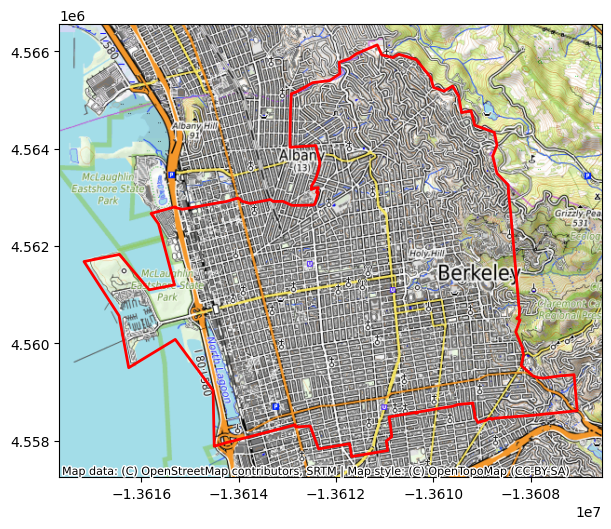

In [24]:
ax = berkeley.plot(ec='r',fc='none',figsize=(7, 7),lw=2)
cx.add_basemap(ax,source=cx.providers.OpenTopoMap)
plt.show()

To get the OSM HOT tiles:

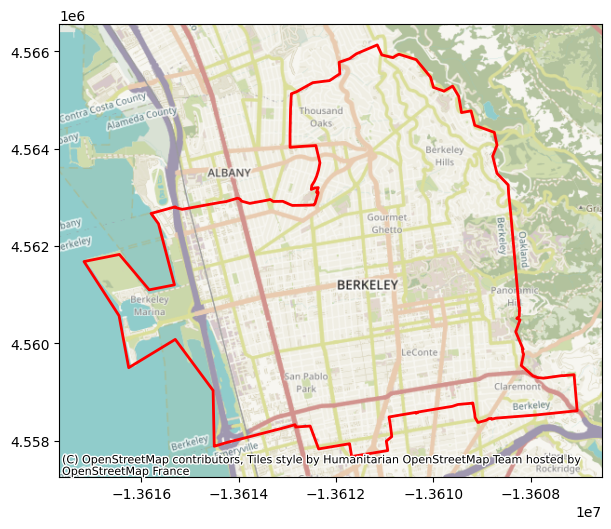

In [25]:
ax = berkeley.plot(ec='r',fc='none',figsize=(7, 7),lw=2)
cx.add_basemap(ax,source=cx.providers.OpenStreetMap.HOT)
plt.show()

### contextily.Place

There is also the Place API

In [26]:
from matplotlib import pyplot as plt
from contextily import Place

madrid = Place("Madrid")
madrid.zoom

11

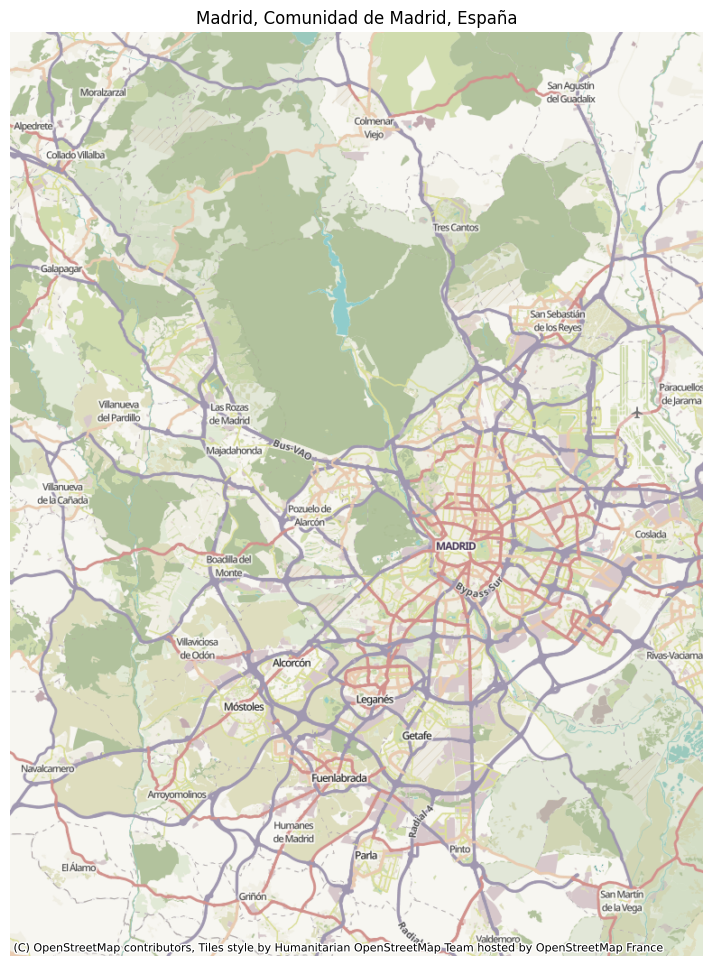

In [27]:
madrid.n_tilesax = madrid.plot()
plt.show()

In [28]:
madrid.n_tiles

1

In [29]:
print(madrid.longitude,madrid.latitude)

-3.7035825 40.4167047
